In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
PROCESSED_PATH = Path("../outputs/attention/lstm_attention_weights.parquet")

df = pd.read_parquet(PROCESSED_PATH)
df['datetime'] = df['datetime'].sort_values(ascending=True)
print(df.shape)
df.head()

(428, 26)


,datetime,attn_t_minus_24,attn_t_minus_23,attn_t_minus_22,attn_t_minus_21,attn_t_minus_20,attn_t_minus_19,attn_t_minus_18,attn_t_minus_17,attn_t_minus_16,...,attn_t_minus_9,attn_t_minus_8,attn_t_minus_7,attn_t_minus_6,attn_t_minus_5,attn_t_minus_4,attn_t_minus_3,attn_t_minus_2,attn_t_minus_1,model
0,2024-06-08 04:00:00,0.121262,0.106271,0.100296,0.097222,0.107865,0.082670,0.049326,0.031018,0.018931,...,0.027630,0.017183,0.013082,0.012415,0.012093,0.011048,0.010875,0.011927,0.017259,lstm_attention
1,2024-06-08 05:00:00,0.131108,0.113273,0.106705,0.119800,0.089481,0.050975,0.029520,0.018200,0.013213,...,0.017492,0.013066,0.012413,0.012155,0.011135,0.010966,0.012049,0.017741,0.043950,lstm_attention
2,2024-06-08 06:00:00,0.118157,0.104055,0.122864,0.090481,0.049010,0.025994,0.016201,0.011801,0.011416,...,0.011011,0.010397,0.010241,0.009437,0.009341,0.010224,0.015093,0.038353,0.182374,lstm_attention
3,2024-06-08 07:00:00,0.072555,0.092525,0.067626,0.034169,0.016518,0.010380,0.007400,0.006817,0.008169,...,0.005772,0.005695,0.005283,0.005285,0.005700,0.008117,0.019781,0.089933,0.458093,lstm_attention
4,2024-06-08 08:00:00,0.048961,0.037096,0.017517,0.007676,0.004659,0.003150,0.002737,0.002741,0.003746,...,0.002051,0.001909,0.001941,0.002069,0.002786,0.006231,0.026868,0.163354,0.639068,lstm_attention


In [4]:
attention_cols = [col for col in df.columns if col.startswith("attn_")]

df[attention_cols].sum(axis=1).head()

0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
dtype: float32

In [6]:
row = df.loc[0]
forecast_time = row["datetime"]

attn_readable = pd.DataFrame({
    "lag": list(range(24, 0, -1)),
    "past_datetime": [forecast_time - pd.Timedelta(hours=i) for i in range(24, 0, -1)],
    "attention_weight": row[attention_cols].values
})

attn_readable.sort_values("attention_weight", ascending=False).head(10)

,lag,past_datetime,attention_weight
0,24,2024-06-07 04:00:00,0.121262
4,20,2024-06-07 08:00:00,0.107865
1,23,2024-06-07 05:00:00,0.106271
2,22,2024-06-07 06:00:00,0.100296
3,21,2024-06-07 07:00:00,0.097222
5,19,2024-06-07 09:00:00,0.08267
6,18,2024-06-07 10:00:00,0.049326
13,11,2024-06-07 17:00:00,0.039703
14,10,2024-06-07 18:00:00,0.039027
7,17,2024-06-07 11:00:00,0.031018


<Axes: title={'center': 'Average attention weight by past hour'}, xlabel='lag'>

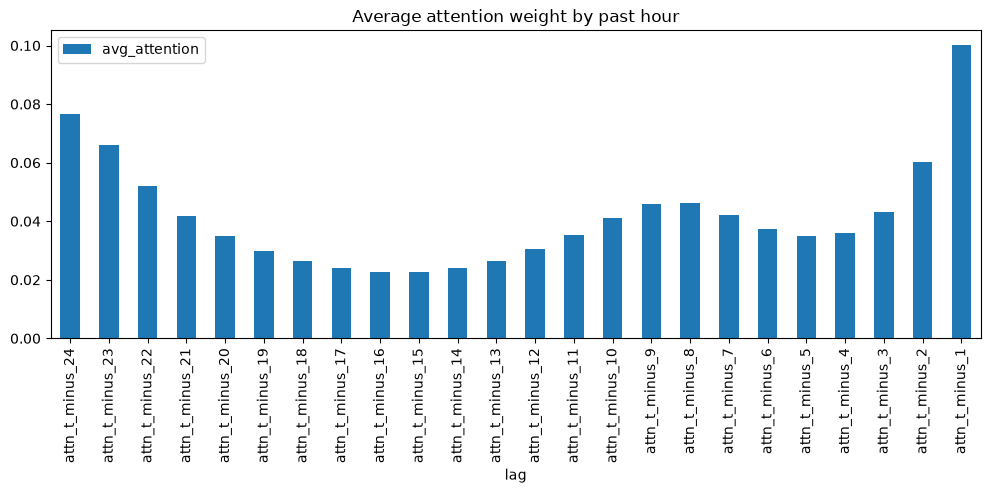

In [8]:
avg_attention = df[attention_cols].mean().reset_index()
avg_attention.columns = ["lag", "avg_attention"]

avg_attention["lag_num"] = avg_attention["lag"].str.extract(r"minus_(\d+)").astype(int)
avg_attention = avg_attention.sort_values("lag_num", ascending=False)

avg_attention.plot(
    x="lag",
    y="avg_attention",
    kind="bar",
    figsize=(12, 4),
    title="Average attention weight by past hour"
)